Load the `ISLR2` and `tidyverse` packages.

In [6]:
library(ISLR2)
library(tidyverse)
library(tidymodels)



── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.9     ✔ rsample      1.3.1
✔ dials        1.4.2     ✔ tailor       0.1.0
✔ infer        1.0.9     ✔ tune         2.0.0
✔ modeldata    1.5.1     ✔ workflows    1.3.0
✔ parsnip      1.3.3     ✔ workflowsets 1.1.1
✔ recipes      1.3.1     ✔ yardstick    1.3.2

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()



`glimpse` the `Auto` dataset (this comes from the `ISLR2` package).

In [2]:

Auto |> glimpse()


Rows: 392
Columns: 9
$ mpg          <dbl> 18, 15, 18, 16, 17, 15, 14, 14, 14, 15, 15, 14, 15, 14, 2…
$ cylinders    <int> 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 4, 6, 6, 6, 4, …
$ displacement <dbl> 307, 350, 318, 304, 302, 429, 454, 440, 455, 390, 383, 34…
$ horsepower   <int> 130, 165, 150, 150, 140, 198, 220, 215, 225, 190, 170, 16…
$ weight       <int> 3504, 3693, 3436, 3433, 3449, 4341, 4354, 4312, 4425, 385…
$ acceleration <dbl> 12.0, 11.5, 11.0, 12.0, 10.5, 10.0, 9.0, 8.5, 10.0, 8.5, …
$ year         <int> 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 7…
$ origin       <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 3, …
$ name         <fct> chevrolet chevelle malibu, buick skylark 320, plymouth sa…


Plot `mpg`  as a function of `displacement`.

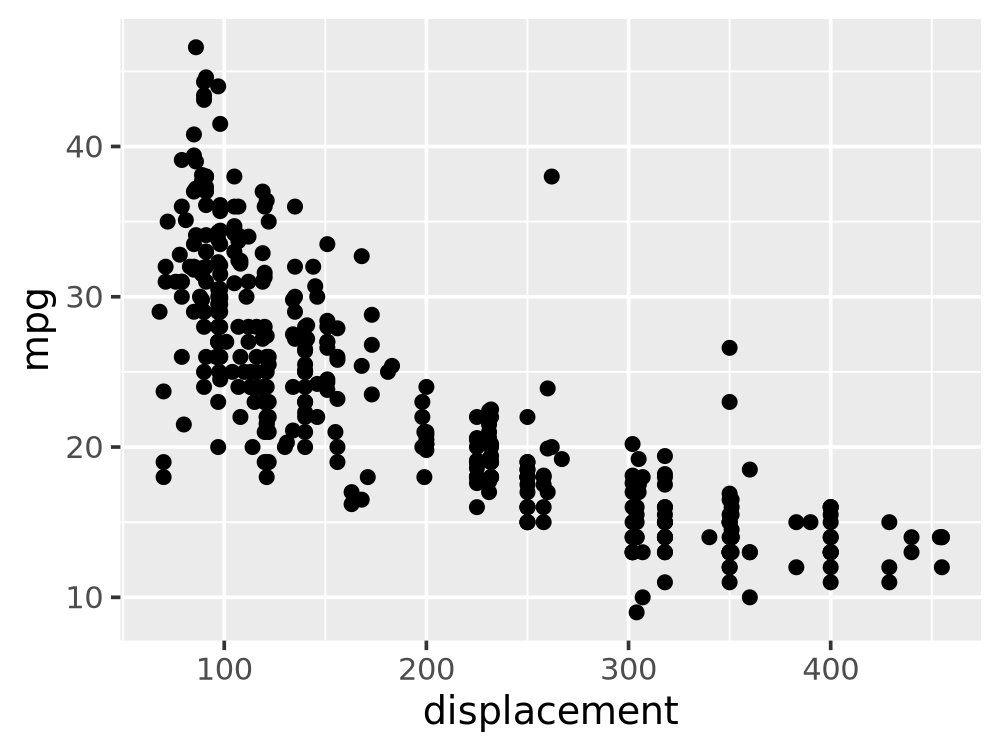

In [4]:
options(repr.plot.res = 250, repr.plot.height=3, repr.plot.width=4)
ggplot(Auto, aes(x=displacement, y=mpg)) + geom_point()



❓Does the relationship of `mpg` to `displacement` look linear?

## not quite linear, more of a log/exponential curve



Model `mpg` as a function of `displacement` and `cylinders`. 

- Transform the `displacement` variable using a `spline` or `polynomial` transform. (Hint: use `step_ns` or `step_poly`).
- Combine `step_mutate(cyl_cat = factor(cylinders))` followed by `step_dummy(cyl_cat)` and `step_rm(cylinders)` to convert `cylinders` to categorical data for the model.

Assuming you name your fitted model `mod_fit` the code below can be used to visualize your model:

```r
predict(mod_fit, rec |> juice()) |>
    bind_cols(Auto) |>
ggplot(aes(x = displacement, y = mpg)) +
    geom_point(size = 1, alpha = 0.35) +
    geom_line(aes(y = .pred, color = factor(cylinders)), linewidth = 1)
```

**Create and visualize your model below...**

In [18]:
rec = recipe(mpg ~ cylinders + displacement , data=Auto) |> 
  step_mutate(cyl_cat = factor(cylinders)) |>
  step_dummy(cyl_cat) |>
  step_rm(cylinders) |>
  step_ns(displacement,deg_free=5) |>   
  prep()

rec |> juice() |> head()

mod = linear_reg() |> set_engine('lm')

mod_fit = mod |> fit(mpg ~  . , data=rec |> juice())


mpg,cyl_cat_X4,cyl_cat_X5,cyl_cat_X6,cyl_cat_X8,displacement_ns_1,displacement_ns_2,displacement_ns_3,displacement_ns_4,displacement_ns_5
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18,0,0,0,1,0.000000e+00,0.282177134,0.56118203,0.1970569,-0.04041604
15,0,0,0,1,0.000000e+00,0.100763807,0.53367220,0.2690665,0.09649752
18,0,0,0,1,0.000000e+00,0.223819733,0.57591385,0.2171284,-0.01686203
16,0,0,0,1,3.299807e-07,0.299685945,0.55426107,0.1913627,-0.04531008
17,0,0,0,1,8.909480e-06,0.311732027,0.54894655,0.1875145,-0.04820201
15,0,0,0,1,0.000000e+00,0.001529878,0.05672152,0.3690335,0.57271515


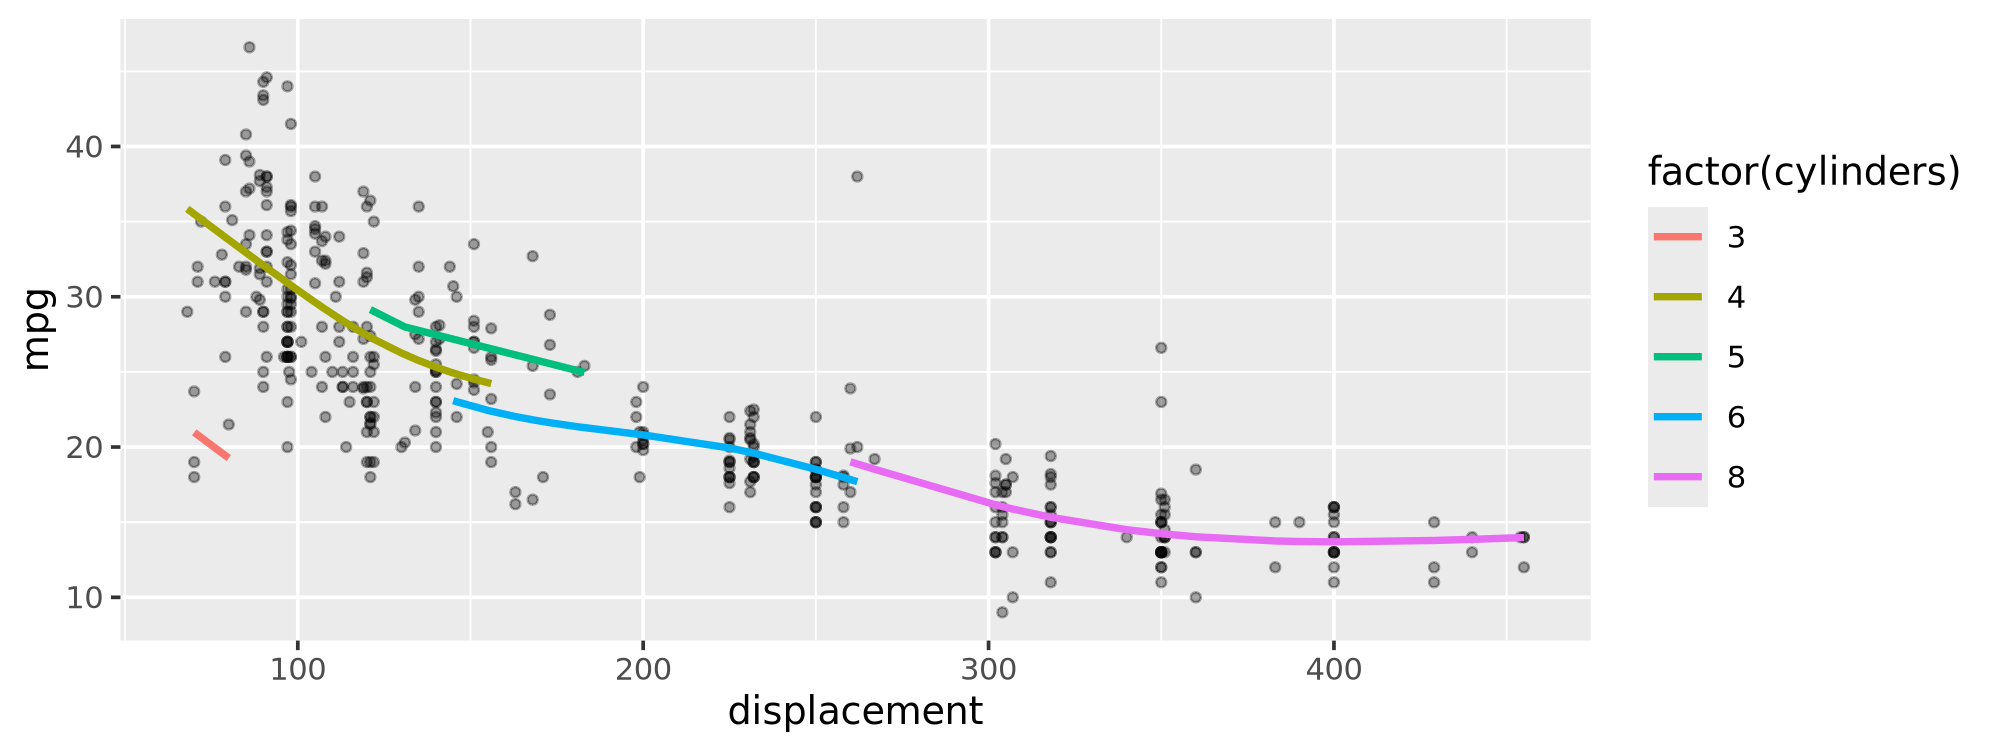

In [20]:
options(repr.plot.res = 250, repr.plot.height=3, repr.plot.width=8)
predict(mod_fit, rec |> juice()) |>
    bind_cols(Auto) |>
ggplot(aes(x = displacement, y = mpg)) +
    geom_point(size = 1, alpha = 0.35) +
    geom_line(aes(y = .pred, color = factor(cylinders)), linewidth = 1)